In [1]:
# ==========================================================
# Taxi Fare Prediction Project
# Cell 1 : Import Required Libraries
# ==========================================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Save & Load Model
import joblib

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("=" * 60)
print("✅ All Libraries Imported Successfully")
print("=" * 60)

✅ All Libraries Imported Successfully


In [2]:
# ==========================================================
# Cell 2 : Load Dataset
# ==========================================================

# Load Dataset
df = pd.read_csv("../data/data.csv")

print("✅ Dataset Loaded Successfully")

✅ Dataset Loaded Successfully


In [3]:
# ==========================================================
# Cell 3 : Display Dataset
# ==========================================================

print("First 5 Rows")
display(df.head())

print("\n")

print("Last 5 Rows")
display(df.tail())

First 5 Rows


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,1.0,2020-01-01 00:28:15,2020-01-01 00:33:03,1.0,1.2,1.0,N,238,239,1.0,6.0,3.0,0.5,1.47,0.0,0.3,11.27,2.5
1,1.0,2020-01-01 00:35:39,2020-01-01 00:43:04,1.0,1.2,1.0,N,239,238,1.0,7.0,3.0,0.5,1.50,0.0,0.3,12.30,2.5
2,1.0,2020-01-01 00:47:41,2020-01-01 00:53:52,1.0,0.6,1.0,N,238,238,1.0,6.0,3.0,0.5,1.00,0.0,0.3,10.80,2.5
3,1.0,2020-01-01 00:55:23,2020-01-01 01:00:14,1.0,0.8,1.0,N,238,151,1.0,5.5,0.5,0.5,1.36,0.0,0.3,8.16,0.0
4,2.0,2020-01-01 00:01:58,2020-01-01 00:04:16,1.0,0.0,1.0,N,193,193,2.0,3.5,0.5,0.5,0.00,0.0,0.3,4.80,0.0




Last 5 Rows


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
6405003,NaN,2020-01-31 22:51:00,2020-01-31 23:22:00,NaN,3.24,NaN,NaN,237,234,NaN,17.59,2.75,0.5,0.0,0.00,0.3,21.14,0.0
6405004,NaN,2020-01-31 22:10:00,2020-01-31 23:26:00,NaN,22.13,NaN,NaN,259,45,NaN,46.67,2.75,0.5,0.0,12.24,0.3,62.46,0.0
6405005,NaN,2020-01-31 22:50:07,2020-01-31 23:17:57,NaN,10.51,NaN,NaN,137,169,NaN,48.85,2.75,0.0,0.0,0.00,0.3,51.90,0.0
6405006,NaN,2020-01-31 22:25:53,2020-01-31 22:48:32,NaN,5.49,NaN,NaN,50,42,NaN,27.17,2.75,0.0,0.0,0.00,0.3,30.22,0.0
6405007,NaN,2020-01-31 22:44:00,2020-01-31 23:06:00,NaN,11.60,NaN,NaN,179,205,NaN,54.56,2.75,0.5,0.0,0.00,0.3,58.11,0.0


In [4]:
# ==========================================================
# Cell 4 : Dataset Shape
# ==========================================================

print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 6405008
Number of Columns : 18


In [5]:
# ==========================================================
# Cell 5 : Dataset Information
# ==========================================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6405008 entries, 0 to 6405007
Data columns (total 18 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               float64
 1   tpep_pickup_datetime   str    
 2   tpep_dropoff_datetime  str    
 3   passenger_count        float64
 4   trip_distance          float64
 5   RatecodeID             float64
 6   store_and_fwd_flag     str    
 7   PULocationID           int64  
 8   DOLocationID           int64  
 9   payment_type           float64
 10  fare_amount            float64
 11  extra                  float64
 12  mta_tax                float64
 13  tip_amount             float64
 14  tolls_amount           float64
 15  improvement_surcharge  float64
 16  total_amount           float64
 17  congestion_surcharge   float64
dtypes: float64(13), int64(2), str(3)
memory usage: 1.1 GB


In [6]:
# ==========================================================
# Cell 6 : Check Missing Values
# ==========================================================

print("="*60)
print("Missing Values")
print("="*60)

missing_values = df.isnull().sum()

missing_df = pd.DataFrame({
    "Column": missing_values.index,
    "Missing Values": missing_values.values,
    "Percentage": (missing_values.values / len(df)) * 100
})

display(missing_df)

print("\nColumns with Missing Values:\n")
display(missing_df[missing_df["Missing Values"] > 0])

Missing Values


,Column,Missing Values,Percentage
0,VendorID,65441,1.021716
1,tpep_pickup_datetime,0,0.000000
2,tpep_dropoff_datetime,0,0.000000
3,passenger_count,65441,1.021716
4,trip_distance,0,0.000000
5,RatecodeID,65441,1.021716
6,store_and_fwd_flag,65441,1.021716
7,PULocationID,0,0.000000
8,DOLocationID,0,0.000000
9,payment_type,65441,1.021716



Columns with Missing Values:



,Column,Missing Values,Percentage
0,VendorID,65441,1.021716
3,passenger_count,65441,1.021716
5,RatecodeID,65441,1.021716
6,store_and_fwd_flag,65441,1.021716
9,payment_type,65441,1.021716


In [7]:
# ==========================================================
# Cell 7 : Check Duplicate Records
# ==========================================================

duplicates = df.duplicated().sum()

print("="*60)
print("Duplicate Records")
print("="*60)

print(f"Total Duplicate Rows : {duplicates}")

Duplicate Records
Total Duplicate Rows : 12949


In [8]:
# ==========================================================
# Cell 8 : Statistical Summary
# ==========================================================

display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
VendorID,6339567.0,1.669624,0.470348,1.00,1.00,2.00,2.00,2.00
passenger_count,6339567.0,1.515333,1.151594,0.00,1.00,1.00,2.00,9.00
trip_distance,6405008.0,2.929644,83.159106,-30.62,0.96,1.60,2.93,210240.07
RatecodeID,6339567.0,1.059908,0.811843,1.00,1.00,1.00,1.00,99.00
PULocationID,6405008.0,164.732258,65.543739,1.00,132.00,162.00,234.00,265.00
DOLocationID,6405008.0,162.662691,69.912606,1.00,113.00,162.00,234.00,265.00
payment_type,6339567.0,1.270298,0.473999,1.00,1.00,1.00,2.00,5.00
fare_amount,6405008.0,12.694108,12.127295,-1238.00,6.50,9.00,14.00,4265.00
extra,6405008.0,1.115456,1.260054,-27.00,0.00,0.50,2.50,113.01
mta_tax,6405008.0,0.492318,0.073742,-0.50,0.50,0.50,0.50,30.80


In [9]:
# ==========================================================
# Cell 9 : Unique Values
# ==========================================================

for column in df.columns:
    print(f"{column} : {df[column].nunique()} unique values")

VendorID : 2 unique values
tpep_pickup_datetime : 2134342 unique values
tpep_dropoff_datetime : 2137286 unique values
passenger_count : 10 unique values
trip_distance : 5606 unique values
RatecodeID : 7 unique values
store_and_fwd_flag : 2 unique values
PULocationID : 261 unique values
DOLocationID : 262 unique values
payment_type : 5 unique values
fare_amount : 5283 unique values
extra : 47 unique values
mta_tax : 11 unique values
tip_amount : 3626 unique values
tolls_amount : 1035 unique values
improvement_surcharge : 3 unique values
total_amount : 12488 unique values
congestion_surcharge : 8 unique values


In [10]:
# ==========================================================
# Cell 10 : Random Sample
# ==========================================================

display(df.sample(10, random_state=42))

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
3340840,2.0,2020-01-17 18:18:36,2020-01-17 18:46:24,1.0,3.60,1.0,N,264,264,1.0,18.5,1.0,0.5,4.56,0.0,0.3,27.36,2.5
4887036,2.0,2020-01-25 10:49:58,2020-01-25 11:07:35,1.0,3.28,1.0,N,142,246,1.0,14.0,0.0,0.5,1.70,0.0,0.3,19.00,2.5
2737398,2.0,2020-01-15 07:30:08,2020-01-15 07:40:01,1.0,1.75,1.0,N,238,166,1.0,8.5,0.0,0.5,1.20,0.0,0.3,13.00,2.5
1452246,2.0,2020-01-09 06:29:09,2020-01-09 06:35:44,1.0,0.87,1.0,N,100,164,2.0,5.5,0.0,0.5,0.00,0.0,0.3,8.80,2.5
5124188,2.0,2020-01-26 12:24:04,2020-01-26 12:29:15,2.0,0.98,1.0,N,161,43,2.0,5.5,0.0,0.5,0.00,0.0,0.3,8.80,2.5
5883778,1.0,2020-01-30 07:57:53,2020-01-30 08:10:19,1.0,1.30,1.0,N,229,262,1.0,9.0,2.5,0.5,2.45,0.0,0.3,14.75,2.5
5820088,1.0,2020-01-29 20:41:22,2020-01-29 20:48:08,1.0,0.60,1.0,N,162,161,1.0,6.0,3.0,0.5,2.45,0.0,0.3,12.25,2.5
5270552,2.0,2020-01-27 08:13:10,2020-01-27 08:15:26,2.0,0.35,1.0,N,164,90,1.0,3.5,0.0,0.5,1.36,0.0,0.3,8.16,2.5
2178248,1.0,2020-01-12 12:00:28,2020-01-12 12:06:04,1.0,1.10,1.0,N,238,142,1.0,6.0,2.5,0.5,1.85,0.0,0.3,11.15,2.5
3218467,2.0,2020-01-17 09:50:22,2020-01-17 09:58:50,5.0,0.96,1.0,N,237,161,1.0,7.0,0.0,0.5,2.58,0.0,0.3,12.88,2.5


In [11]:
# ==========================================================
# Cell 11 : Remove Duplicate Rows
# ==========================================================

print("Shape Before Removing Duplicates :", df.shape)

df = df.drop_duplicates()

print("Shape After Removing Duplicates :", df.shape)

Shape Before Removing Duplicates : (6405008, 18)
Shape After Removing Duplicates : (6392059, 18)


In [12]:
# ==========================================================
# Cell 12 : Handle Missing Values
# ==========================================================

print("Missing Values Before Cleaning")

print(df.isnull().sum())

df = df.dropna()

print("\nMissing Values After Cleaning")

print(df.isnull().sum())

Missing Values Before Cleaning
VendorID                 52492
tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          52492
trip_distance                0
RatecodeID               52492
store_and_fwd_flag       52492
PULocationID                 0
DOLocationID                 0
payment_type             52492
fare_amount                  0
extra                        0
mta_tax                      0
tip_amount                   0
tolls_amount                 0
improvement_surcharge        0
total_amount                 0
congestion_surcharge         0
dtype: int64

Missing Values After Cleaning
VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount      

In [13]:
# ==========================================================
# Cell 13 : Convert Datetime Columns
# ==========================================================

df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])

df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])

print("Datetime conversion completed!")

Datetime conversion completed!


In [14]:
# ==========================================================
# Cell 14 : Encode store_and_fwd_flag
# ==========================================================

df["store_and_fwd_flag"] = df["store_and_fwd_flag"].map({
    "N": 0,
    "Y": 1
})

print(df["store_and_fwd_flag"].value_counts())

store_and_fwd_flag
0    6271447
1      68120
Name: count, dtype: int64


In [15]:
# ==========================================================
# Cell 15 : Verify Data Types
# ==========================================================

df.info()

<class 'pandas.DataFrame'>
Index: 6339567 entries, 0 to 6339566
Data columns (total 18 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               float64       
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     int64         
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           float64       
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
dtypes: datetime64[us](2), float64(13), int

In [16]:
# ==========================================================
# Cell 16 : Remove Invalid Values
# ==========================================================

print("Shape Before Cleaning :", df.shape)

df = df[
    (df["trip_distance"] > 0) &
    (df["fare_amount"] > 0) &
    (df["passenger_count"] > 0) &
    (df["total_amount"] > 0)
]

print("Shape After Cleaning :", df.shape)

Shape Before Cleaning : (6339567, 18)
Shape After Cleaning : (6141444, 18)


In [17]:
# ==========================================================
# Cell 17 : Feature Engineering
# ==========================================================

df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour
df["pickup_day"] = df["tpep_pickup_datetime"].dt.day
df["pickup_month"] = df["tpep_pickup_datetime"].dt.month
df["pickup_weekday"] = df["tpep_pickup_datetime"].dt.weekday

print("Time Features Created Successfully!")

Time Features Created Successfully!


In [18]:
# ==========================================================
# Cell 18 : Trip Duration
# ==========================================================

df["trip_duration"] = (
    df["tpep_dropoff_datetime"] -
    df["tpep_pickup_datetime"]
).dt.total_seconds() / 60

print("Trip Duration Feature Created!")

Trip Duration Feature Created!


In [19]:
# ==========================================================
# Cell 19 : Remove Invalid Trip Durations
# ==========================================================

print("Before :", df.shape)

df = df[df["trip_duration"] > 0]

print("After :", df.shape)

Before : (6141444, 23)
After : (6141262, 23)


In [20]:
# ==========================================================
# Cell 20 : Drop Datetime Columns
# ==========================================================

df.drop(
    columns=[
        "tpep_pickup_datetime",
        "tpep_dropoff_datetime"
    ],
    inplace=True
)

print(df.head())

   VendorID  passenger_count  trip_distance  RatecodeID  store_and_fwd_flag  \
0       1.0              1.0           1.20         1.0                   0   
1       1.0              1.0           1.20         1.0                   0   
2       1.0              1.0           0.60         1.0                   0   
3       1.0              1.0           0.80         1.0                   0   
5       2.0              1.0           0.03         1.0                   0   

   PULocationID  DOLocationID  payment_type  fare_amount  extra  mta_tax  \
0           238           239           1.0          6.0    3.0      0.5   
1           239           238           1.0          7.0    3.0      0.5   
2           238           238           1.0          6.0    3.0      0.5   
3           238           151           1.0          5.5    0.5      0.5   
5             7           193           2.0          2.5    0.5      0.5   

   tip_amount  tolls_amount  improvement_surcharge  total_amount  \


In [21]:
# ==========================================================
# Cell 21 : Remove Data Leakage Columns
# ==========================================================

columns_to_drop = [
    "extra",
    "mta_tax",
    "tip_amount",
    "tolls_amount",
    "improvement_surcharge",
    "total_amount",
    "congestion_surcharge"
]

df.drop(columns=columns_to_drop, inplace=True)

print("Columns Removed Successfully!")

print("\nRemaining Columns:")
print(df.columns.tolist())

Columns Removed Successfully!

Remaining Columns:
['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'pickup_hour', 'pickup_day', 'pickup_month', 'pickup_weekday', 'trip_duration']


In [22]:
# ==========================================================
# Cell 22 : Final Dataset
# ==========================================================

print("Final Dataset Shape :", df.shape)

display(df.head())

Final Dataset Shape : (6141262, 14)


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,pickup_hour,pickup_day,pickup_month,pickup_weekday,trip_duration
0,1.0,1.0,1.20,1.0,0,238,239,1.0,6.0,0,1,1,2,4.800000
1,1.0,1.0,1.20,1.0,0,239,238,1.0,7.0,0,1,1,2,7.416667
2,1.0,1.0,0.60,1.0,0,238,238,1.0,6.0,0,1,1,2,6.183333
3,1.0,1.0,0.80,1.0,0,238,151,1.0,5.5,0,1,1,2,4.850000
5,2.0,1.0,0.03,1.0,0,7,193,2.0,2.5,0,1,1,2,0.883333


In [23]:
# ==========================================================
# Cell 23 : Create Sample Dataset
# ==========================================================

print("Original Dataset Shape :", df.shape)

df_sample = df.sample(n=200000, random_state=42)

print("Sample Dataset Shape :", df_sample.shape)

Original Dataset Shape : (6141262, 14)
Sample Dataset Shape : (200000, 14)


In [24]:
# ==========================================================
# Cell 24 : Features and Target
# ==========================================================

X = df_sample.drop("fare_amount", axis=1)
y = df_sample["fare_amount"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

print("\nFeatures Used:")
print(X.columns.tolist())

Feature Shape : (200000, 13)
Target Shape : (200000,)

Features Used:
['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'pickup_hour', 'pickup_day', 'pickup_month', 'pickup_weekday', 'trip_duration']


In [25]:
# ==========================================================
# Cell 25 : Train Test Split
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data :", X_train.shape)
print("Testing Data  :", X_test.shape)

Training Data : (160000, 13)
Testing Data  : (40000, 13)


In [34]:
# ==========================================================
# Cell 26 : Train Random Forest Model
# ==========================================================

model = RandomForestRegressor(
    n_estimators=30,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

print("Training Model...")

model.fit(X_train, y_train)

print("✅ Model Trained Successfully!")

Training Model...
✅ Model Trained Successfully!


In [35]:
# ==========================================================
# Cell 27 : Predict on Test Data
# ==========================================================

y_pred = model.predict(X_test)

print("Prediction Completed Successfully!")

Prediction Completed Successfully!


In [36]:
# ==========================================================
# Cell 28 : Model Evaluation
# ==========================================================

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import numpy as np

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("="*60)
print("MODEL PERFORMANCE")
print("="*60)

print(f"Mean Absolute Error : {mae:.4f}")

print(f"Root Mean Squared Error : {rmse:.4f}")

print(f"R² Score : {r2:.4f}")

MODEL PERFORMANCE
Mean Absolute Error : 0.3435
Root Mean Squared Error : 2.5175
R² Score : 0.9539


In [37]:
# ==========================================================
# Cell 29 : Actual vs Predicted Values
# ==========================================================

comparison = pd.DataFrame({
    "Actual Fare": y_test.values,
    "Predicted Fare": y_pred
})

display(comparison.head(20))

,Actual Fare,Predicted Fare
0,25.0,25.620213
1,21.5,21.204254
2,52.0,52.109333
3,13.0,13.035061
4,6.5,6.456019
5,14.5,14.408754
6,6.0,6.146159
7,6.5,6.508958
8,8.5,8.413861
9,9.0,9.017647


In [38]:
# ==========================================================
# Cell 30 : Feature Importance
# ==========================================================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance)

,Feature,Importance
2,trip_distance,0.854531
3,RatecodeID,0.072986
12,trip_duration,0.056556
5,PULocationID,0.005501
6,DOLocationID,0.002648
9,pickup_day,0.002164
8,pickup_hour,0.001794
7,payment_type,0.001679
11,pickup_weekday,0.001229
1,passenger_count,0.000605


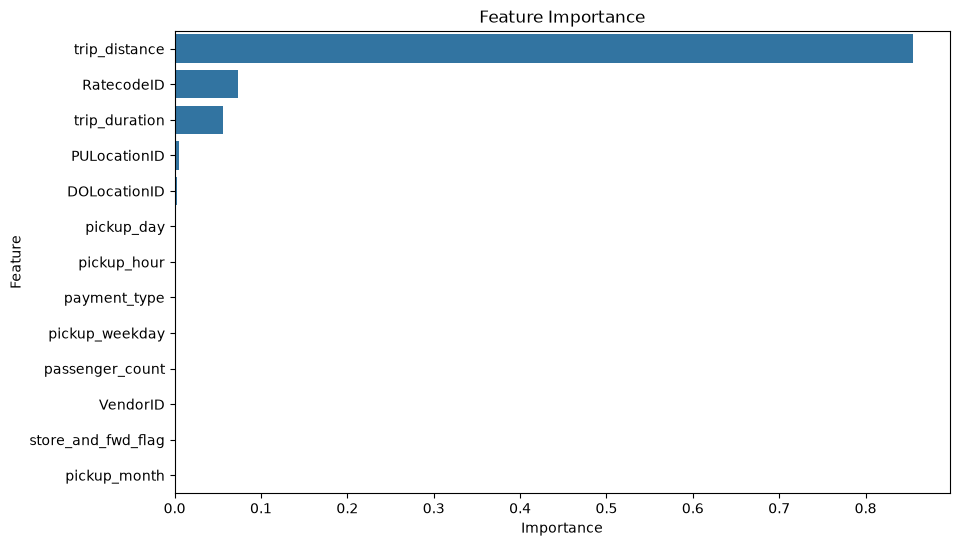

In [39]:
# ==========================================================
# Cell 31 : Feature Importance Plot
# ==========================================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

In [40]:
# ==========================================================
# Cell 32 : Save Model
# ==========================================================

joblib.dump(
    model,
    "../models/taxi_fare_model.pkl"
)

print("✅ Model Saved Successfully!")

✅ Model Saved Successfully!


In [41]:
# ==========================================================
# Cell 33 : Save Feature Importance
# ==========================================================

feature_importance.to_csv(
    "../models/feature_importance.csv",
    index=False
)

print("✅ Feature Importance Saved!")

✅ Feature Importance Saved!
